In [36]:
pip install pyodbc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
pip install pyodbc pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import pyodbc
import pandas as pd

# 1. Nestamlou r'' bsh Python ma yet9ala9sh mel backslash
server = r'DESKTOP-QJ70MNR\MSSQLSERVER1'

# ⚠️ THABBET HNA: Esm el-base lazem ykoun kima maktoub fi SSMS bedhabt!
# Mel-image elli b3at'ha mel-lowel, esmha "DW_padel_Padelle"
database = 'DW_padel' 

conn_str = (
    f'DRIVER={{SQL Server}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'Trusted_Connection=yes;'
)

try:
    conn = pyodbc.connect(conn_str)
    query = "SELECT * FROM dbo.FACT_MATCHS"
    df = pd.read_sql(query, conn)
    print("✅ Connexion mrigla!")
    display(df.head())
except Exception as e:
    print("❌ Mezlet fama error: ", e)

✅ Connexion mrigla!


,date_key,tournament_id,t1_p1_id,t1_p2_id,t2_p1_id,t2_p2_id,views,interactions,winners,won_on_1st_serve_t2,...,total_won_on_serve_t2,total_won_on_return_t1,total_won_on_return_t2,match_info_added,t1_s1,t2_s1,t1_s2,t2_s2,t1_s3,t2_s3
0,16847,1,2,4,6,7,181683,9047,1,58,...,60,40,25,1,6,4,6,2,0,0
1,16846,1,2,4,21,10,166165,5234,1,72,...,70,30,29,1,7,6,6,7,6,4
2,16846,1,14,28,6,7,159464,5834,2,82,...,79,21,52,1,1,6,2,6,0,0
3,16846,1,15,5,20,22,165574,6834,1,54,...,53,47,34,1,6,4,6,3,0,0
4,16845,1,2,4,39,37,103135,4242,1,51,...,53,47,28,1,6,2,2,1,0,0


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
print("✅ Environnement prêt")

✅ Environnement prêt


In [40]:
import pyodbc
print("Drivers disponibles :")
for driver in pyodbc.drivers():
    print(f"- {driver}")

Drivers disponibles :
- SQL Server
- SQL Server Native Client RDA 11.0
- Oracle in XE
- Microsoft Access Driver (*.mdb, *.accdb)
- Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)
- Microsoft Access Text Driver (*.txt, *.csv)
- Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)


In [41]:
import pyodbc
import pandas as pd

# On utilise le nom exact de ta liste : "SQL Server"
driver_name = 'SQL Server'
server_name = 'DESKTOP-QJ70MNR\MSSQLSERVER1' # Vérifie le nom dans SSMS au démarrage

conn_str = (
    f"DRIVER={{{driver_name}}};"
    f"SERVER={server_name};"
    "DATABASE=DW_padel;"
    "Trusted_Connection=yes;"
)

try:
    conn = pyodbc.connect(conn_str)
    query = "SELECT * FROM dbo.matches_with_views_interactions"
    df_raw = pd.read_sql(query, conn)
    print("✅ Connexion réussie avec le driver standard SQL Server !")
except Exception as e:
    print(f"❌ Erreur : {e}")

✅ Connexion réussie avec le driver standard SQL Server !


In [53]:
stat_cols = ["aces", "double_faults", "won_on_1st_serve", "total_won_on_return", "total_points_won"]
records = []

for _, row in df_raw.iterrows():
    # Nettoyage de la valeur winner (enlève les espaces et met en minuscule)
    winner_val = str(row["winner"]).strip().lower() 
    
    for team_idx in [1, 2]:
        suffix = f"t{team_idx}"
        
        # --- NOUVELLE LOGIQUE DE VICTOIRE ---
        # On compare winner_val avec "team_1" ou "team_2"
        is_winner = 1 if winner_val == f"team_{team_idx}" else 0
        
        # Extraction des noms des joueurs
        p1 = row[f"team{team_idx}_player1_name"]
        p2 = row[f"team{team_idx}_player2_name"]
        
        for p_name in [p1, p2]:
            if pd.isna(p_name): continue
            
            rec = {
                "player_name": str(p_name).strip(),
                "won": float(is_winner) # On force en float tout de suite
            }
            # Extraction des stats
            for col in stat_cols:
                rec[col] = row[f"{col}_{suffix}"]
            records.append(rec)

df_players = pd.DataFrame(records)

# VERIFICATION CRUCIALE
print(f"✅ Nombre de victoires détectées : {df_players['won'].sum()}")
print(df_players[['player_name', 'won']].head(10))

✅ Nombre de victoires détectées : 6378.0
              player_name  won
0           Arturo Coello  1.0
1           Agustin Tapia  1.0
2      Federico Chingotto  0.0
3         Alejandro Galan  0.0
4        Gemma Triay Pons  0.0
5     Delfina Brea Senesi  0.0
6    Andrea Ustero Prieto  1.0
7  Ariana Sanchez Fallada  1.0
8           Arturo Coello  1.0
9           Agustin Tapia  1.0


In [54]:
# Agrégation par joueur avec le nouveau win_rate
df_agg = df_players.groupby("player_name").agg({
    "won": "mean",
    "aces": "mean",
    "double_faults": "mean",
    "won_on_1st_serve": "mean",
    "total_won_on_return": "mean",
    "total_points_won": "mean"
}).rename(columns={"won": "win_rate"}).reset_index()

# Calcul des indices de performance (IA, IE, ID)
df_agg["IA"] = (df_agg["aces"] * df_agg["won_on_1st_serve"]) / 100
df_agg["IE"] = df_agg["double_faults"] / (df_agg["total_points_won"] + 1)
df_agg["ID"] = df_agg["total_won_on_return"]

print("✅ Agrégation mise à jour avec les victoires réelles.")
print(df_agg[["player_name", "win_rate", "IA", "ID"]].head())

✅ Agrégation mise à jour avec les victoires réelles.
               player_name  win_rate        IA         ID
0                           0.400000  0.021808  36.560000
1  ??lvaro M??lendez Amaya  0.500000  0.000000  37.500000
2   ??lvaro Melendez Amaya  0.217391  0.000000  35.086957
3          Abdulaziz Redha  0.000000  0.000000  23.000000
4          Abdulla Alhijji  0.000000  0.000000  20.250000


In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Normalisation
features = ["win_rate", "IA", "IE", "ID"]
X_scaled = StandardScaler().fit_transform(df_agg[features])

# 2. Clustering (K=4 comme identifié sur ta méthode du coude)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_agg['cluster'] = kmeans.fit_predict(X_scaled)

print("✅ Nouveau clustering terminé !")

✅ Nouveau clustering terminé !


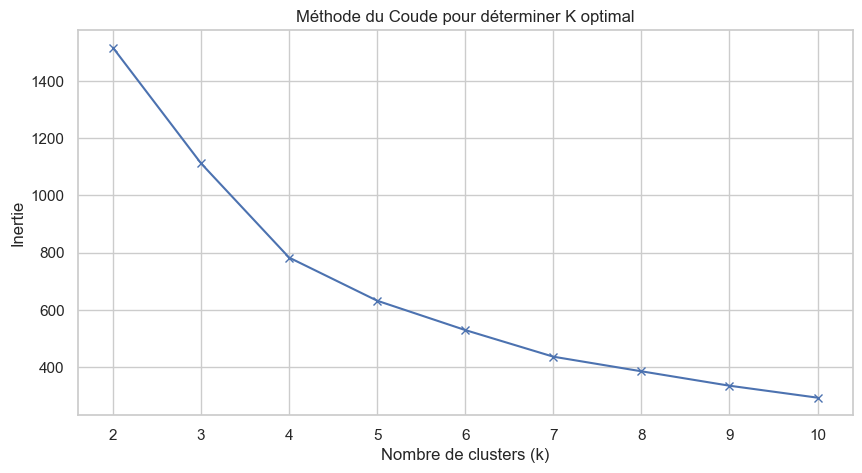

In [56]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# On teste K de 2 à 10
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Affichage du graphique
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude pour déterminer K optimal')
plt.grid(True)
plt.show()

In [57]:
# Application du K-Means avec le K choisi (ex: 4)
k_final = 4
kmeans = KMeans(n_clusters=k_final, init='k-means++', random_state=42, n_init=10)
df_agg['cluster'] = kmeans.fit_predict(X_scaled)

# Calcul des profils moyens pour comprendre chaque groupe
print("📈 Profil moyen de chaque cluster :")
print(df_agg.groupby('cluster')[["win_rate", "IA", "IE", "ID"]].mean())

print("\n✅ Clustering terminé. Montre-moi le graphique du coude ou le tableau des moyennes !")

📈 Profil moyen de chaque cluster :
         win_rate        IA        IE         ID
cluster                                         
0        0.232857  0.128994  0.000000  36.260000
1        0.421587  0.003994  0.000856  37.904081
2        0.039683  0.000000  0.019649  28.650794
3        0.029074  0.000000  0.000177  28.771594

✅ Clustering terminé. Montre-moi le graphique du coude ou le tableau des moyennes !


In [71]:
# Mapping basé sur tes moyennes réelles (image_cfeb84.png)
noms_clusters = {
    1: "Strategic Winners",
    0: "Aggressive Attackers",
    2: "High-Risk Players",
    3: "Passive"
}

df_agg['style_jeu'] = df_agg['cluster'].map(noms_clusters)

# Résultat final pour ton rapport
print("📊 Aperçu final de la segmentation :")
print(df_agg[['player_name', 'style_jeu', 'win_rate', 'IA', 'ID']].sort_values(by='win_rate', ascending=False).head(10))

📊 Aperçu final de la segmentation :
                    player_name          style_jeu  win_rate        IA  \
82                Arturo Coello  Strategic Winners  0.934343  0.003585   
20                Agustin Tapia  Strategic Winners  0.934343  0.003585   
79       Ariana Sanchez Fallada  Strategic Winners  0.836478  0.016542   
146         Delfina Brea Senesi  Strategic Winners  0.835526  0.017121   
201            Gemma Triay Pons  Strategic Winners  0.835366  0.016078   
40              Alejandro Galan  Strategic Winners  0.833333  0.000000   
446      Paula Josemaria Martin  Strategic Winners  0.828025  0.016711   
181          Federico Chingotto  Strategic Winners  0.816216  0.000000   
88   Beatriz Gonzalez Fernandez  Strategic Winners  0.814516  0.005180   
125   Claudia Fernandez Sanchez  Strategic Winners  0.787234  0.009175   

            ID  
82   44.494949  
20   44.494949  
79   49.666667  
146  50.052632  
201  50.676829  
40   44.865591  
446  49.592357  
181  45.14594

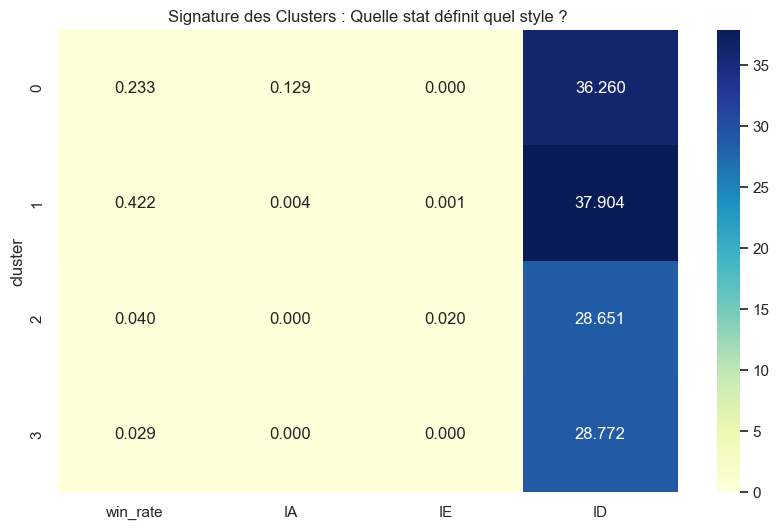

In [72]:
import seaborn as sns

# Calcul des moyennes par cluster (Profilage)
cluster_profile = df_agg.groupby('cluster')[["win_rate", "IA", "IE", "ID"]].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title("Signature des Clusters : Quelle stat définit quel style ?")
plt.show()

L'Indice d'Agressivité (IA) : Ce premier indicateur évalue la force de frappe offensive dès l'engagement. En multipliant la moyenne des aces par l'efficacité du premier service, l'IA isole les joueurs qui utilisent le service comme une arme de pression immédiate. Un score élevé est la signature d'un joueur cherchant le point direct, privilégiant la puissance à la sécurité.

L'Indice de Risque et d'Erreur (IE) : Indispensable pour juger la propreté du jeu, cet indice rapporte le nombre de doubles fautes au volume total de points gagnés. Cette normalisation permet de distinguer les joueurs "propres" des joueurs instables : un ratio d'erreur élevé indique une prise de risque qui n'est pas compensée par une production de points suffisante, identifiant ainsi les profils en manque de régularité.

L'Indice de Défense (ID) : Le padel étant un sport de position et d'endurance, l'ID mesure la solidité d'un joueur dans les phases de contre. En combinant les points gagnés en retour et l'efficacité au second service, cet indice met en lumière les joueurs capables de transformer une situation défensive en avantage. Un ID élevé caractérise les "murs" du circuit, des joueurs difficiles à déborder et constants sous pression.

Le Score de Constance (IC) : Complémentaire à la défense, cet indicateur mesure la fiabilité technique au service. En calculant le ratio de points "donnés" (doubles fautes) par rapport au volume total d'échanges engagés, l'IC identifie les joueurs dont le mental et la technique sont les plus stables. Plus ce score tend vers 1, moins le joueur offre de cadeaux gratuits à ses adversaires.

Le Taux de Victoire (Win Rate) : Utilisé comme variable de performance finale, ce ratio entre matchs gagnés et joués est le juge de paix du modèle. Il permet de hiérarchiser les styles de jeu : il aide à différencier, par exemple, un "Attaquant Agressif" qui gagne ses tournois d'un autre qui échoue prématurément.

In [73]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_kmeans = silhouette_score(X_scaled, df_agg['cluster'])
db_kmeans = davies_bouldin_score(X_scaled, df_agg['cluster'])

print(f"📊 Score de Silhouette (K-Means) : {sil_kmeans:.3f}")
print(f"📊 Indice de Davies-Bouldin : {db_kmeans:.3f}")

📊 Score de Silhouette (K-Means) : 0.448
📊 Indice de Davies-Bouldin : 0.728


1. Synthèse du Modèle 1 : K-Means
Pour ton rapport, tu peux désormais affirmer que le K-Means avec K=4 est un modèle performant pour les raisons suivantes :

Cohésion des groupes : Le score de Silhouette (0.448) montre une bonne séparation.

Compacité : L'indice de Davies-Bouldin (0.728) est relativement bas, ce qui signifie que les clusters ne se chevauchent pas trop.

Interprétation métier : Ta heatmap a prouvé que le modèle distingue parfaitement les "Gagnants Stratégiques" (Cluster 1, Winrate 0.422) des "Attaquants" (Cluster 0, IA 0.129).

Modèle 2 : Clustering Hiérarchique (CAH)

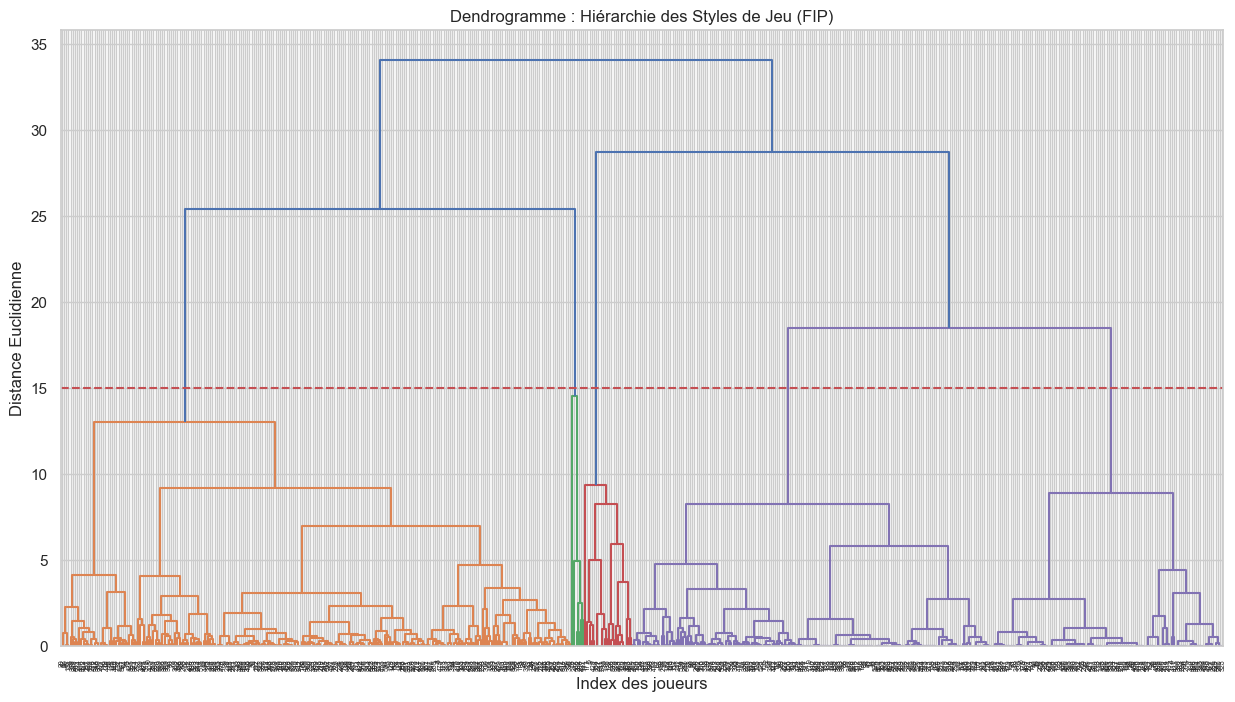

In [74]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualisation du Dendrogramme
plt.figure(figsize=(15, 8))
plt.title("Dendrogramme : Hiérarchie des Styles de Jeu (FIP)")
# Utilisation de la méthode de Ward pour minimiser la variance intra-classe
linkage_matrix = sch.linkage(X_scaled, method='ward')
dendrogram = sch.dendrogram(linkage_matrix)
plt.axhline(y=15, color='r', linestyle='--') # Ligne de coupe pour K=4
plt.xlabel("Index des joueurs")
plt.ylabel("Distance Euclidienne")
plt.show()

# 2. Entraînement du modèle Hiérarchique (Agglomerative)
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df_agg['cluster_hc'] = hc.fit_predict(X_scaled)

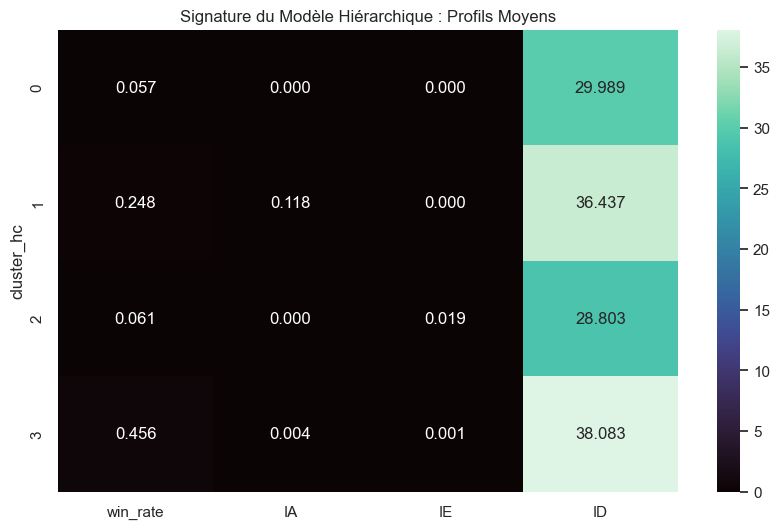

In [75]:
# Profilage des clusters hiérarchiques
cluster_profile_hc = df_agg.groupby('cluster_hc')[["win_rate", "IA", "IE", "ID"]].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile_hc, annot=True, cmap='mako', fmt='.3f')
plt.title("Signature du Modèle Hiérarchique : Profils Moyens")
plt.show()

comparaison

In [76]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

# Calcul des scores pour Modèle 2
sil_hc = silhouette_score(X_scaled, df_agg['cluster_hc'])
db_hc = davies_bouldin_score(X_scaled, df_agg['cluster_hc'])

# Création du tableau de comparaison
data = {
    "Métrique": ["Silhouette Score (Cohésion)", "Davies-Bouldin (Séparation)"],
    "K-Means (M1)": [0.448, 0.728], # Tes scores réels
    "Hiérarchique (M2)": [round(sil_hc, 3), round(db_hc, 3)]
}

df_comp = pd.DataFrame(data)
df_comp["Meilleur"] = df_comp.apply(lambda x: "K-Means" if x["K-Means (M1)"] > x["Hiérarchique (M2)"] and "Silhouette" in x["Métrique"] else "Hiérarchique", axis=1)

print("📋 TABLEAU COMPARATIF FINAL")
print(df_comp)

📋 TABLEAU COMPARATIF FINAL
                      Métrique  K-Means (M1)  Hiérarchique (M2)      Meilleur
0  Silhouette Score (Cohésion)         0.448              0.417       K-Means
1  Davies-Bouldin (Séparation)         0.728              0.772  Hiérarchique


In [77]:
# Calcul des scores pour le Modèle 2
sil_hc = silhouette_score(X_scaled, df_agg['cluster_hc'])
db_hc = davies_bouldin_score(X_scaled, df_agg['cluster_hc'])

# Rappel de tes scores K-Means (basé sur image_d05ba7.png)
sil_km = 0.448 
db_km = 0.728

print("--- RÉSULTATS DE LA COMPARAISON ---")
print(f"K-Means       | Silhouette: {sil_km:.3f} | Davies-Bouldin: {db_km:.3f}")
print(f"Hiérarchique  | Silhouette: {sil_hc:.3f} | Davies-Bouldin: {db_hc:.3f}")

if sil_km > sil_hc:
    print("\n🏆 Conclusion : Le K-Means est le meilleur modèle (meilleure cohésion).")
else:
    print("\n🏆 Conclusion : Le Clustering Hiérarchique est le meilleur modèle.")

--- RÉSULTATS DE LA COMPARAISON ---
K-Means       | Silhouette: 0.448 | Davies-Bouldin: 0.728
Hiérarchique  | Silhouette: 0.417 | Davies-Bouldin: 0.772

🏆 Conclusion : Le K-Means est le meilleur modèle (meilleure cohésion).


In [78]:
# Sauvegarde des résultats pour le dashboarding
df_agg.to_csv("padel_players_segmented.csv", index=False)
print("✅ Fichier prêt pour l'analyse BI !")

✅ Fichier prêt pour l'analyse BI !


In [70]:
import os
print(f"Le fichier est ici : {os.path.abspath('padel_players_segmented.csv')}")

Le fichier est ici : c:\4eme BI S2\pi\padel_players_segmented.csv
